### **1.Consumo di alcol per paese** 
Esegui un’**analisi esplorativa** focalizzata sul **consumo di alcol**.  
Analizza i seguenti aspetti:
* Visualizza i primi 10 paesi ordinati per total_litres_of_pure_alcohol (dal più alto)

* Calcola la media del consumo di birra, vino, e distillati

* Crea una nuova colonna alcohol_index che sia: `(beer_servings + wine_servings + spirit_servings) / 3`

* Trova il paese con il valore massimo di alcohol_index

* Filtra solo i paesi che consumano più di 100 birre all’anno

Crea un bar chart dei 10 paesi con più consumo totale (total_litres_of_pure_alcohol)

Crea un line plot con wine_servings ordinato per paese (usa sort_values)

In [1]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv")
df

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
0,Afghanistan,0,0,0,0.0
1,Albania,89,132,54,4.9
2,Algeria,25,0,14,0.7
3,Andorra,245,138,312,12.4
4,Angola,217,57,45,5.9
...,...,...,...,...,...
188,Venezuela,333,100,3,7.7
189,Vietnam,111,2,1,2.0
190,Yemen,6,0,0,0.1
191,Zambia,32,19,4,2.5


In [2]:
df.sort_values(by='total_litres_of_pure_alcohol', ascending=False)[:10]

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
15,Belarus,142,373,42,14.4
98,Lithuania,343,244,56,12.9
3,Andorra,245,138,312,12.4
68,Grenada,199,438,28,11.9
45,Czech Republic,361,170,134,11.8
61,France,127,151,370,11.8
141,Russian Federation,247,326,73,11.5
81,Ireland,313,118,165,11.4
155,Slovakia,196,293,116,11.4
99,Luxembourg,236,133,271,11.4


In [3]:
print(df['beer_servings'].mean())
print(df['spirit_servings'].mean())
print(df['wine_servings'].mean())

106.16062176165804
80.99481865284974
49.45077720207254


In [4]:
df['alcohol_index'] = (df['beer_servings'] + df['wine_servings'] + df['spirit_servings'] / 3)
df['alcohol_index']


0        0.000000
1      187.000000
2       39.000000
3      603.000000
4      281.000000
          ...    
188    369.333333
189    112.666667
190      6.000000
191     42.333333
192     74.000000
Name: alcohol_index, Length: 193, dtype: float64

In [5]:
df.sort_values(by='alcohol_index', ascending=False).head(1)['country']

3    Andorra
Name: country, dtype: str

In [6]:
df['alcohol_index'].argmax()

np.int64(3)

In [7]:
df[df['alcohol_index'] == df['alcohol_index'].max()]

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,alcohol_index
3,Andorra,245,138,312,12.4,603.0


In [8]:
df[df['beer_servings'] >= 100]

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,alcohol_index
3,Andorra,245,138,312,12.4,603.000000
4,Angola,217,57,45,5.9,281.000000
5,Antigua & Barbuda,102,128,45,4.9,189.666667
6,Argentina,193,25,221,8.3,422.333333
8,Australia,261,72,212,10.4,497.000000
...,...,...,...,...,...,...
182,United Kingdom,219,126,195,10.4,456.000000
184,USA,249,158,84,8.7,385.666667
185,Uruguay,115,35,220,6.6,346.666667
188,Venezuela,333,100,3,7.7,369.333333


### **2.Analisi offerte di lavoro** 

Esegui un’**analisi esplorativa** focalizzata sui **lavori nel campo dei dati in ciascun paese**.  
Analizza i seguenti aspetti per ogni paese:

* Lo **stipendio medio annuale** (`salary_year_avg`)
* Il **numero totale di offerte di lavoro** (job count)
* L’intervallo degli stipendi: **valore minimo e massimo** (`min` / `max`)

Rappresenta graficamente lo stipendio medio (`salary_year_avg`) per `job_title_short` usando un grafico a barre orizzontali. Ordina i dati dallo stipendio più alto al più basso. Includi un titolo e le etichette per gli assi x e y.

In [9]:
import pandas as pd
from datasets import load_dataset

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

/Users/mattia/Documents/uni/I/intro_program/intro_lab_2026/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
df.columns

Index(['job_title_short', 'job_title', 'job_location', 'job_via',
       'job_schedule_type', 'job_work_from_home', 'search_location',
       'job_posted_date', 'job_no_degree_mention', 'job_health_insurance',
       'job_country', 'salary_rate', 'salary_year_avg', 'salary_hour_avg',
       'company_name', 'job_skills', 'job_type_skills'],
      dtype='str')

In [11]:
na_series = df['salary_year_avg'].notna()
df_clean = df[na_series]
df_grouped = df_clean.groupby(by="job_country")

In [12]:
df_grouped['salary_year_avg'].mean()

job_country
Albania        79472.500000
Algeria        44550.000000
Argentina     105212.343750
Armenia        78757.000000
Australia     118987.574324
                  ...      
Uruguay        69333.333333
Uzbekistan     30750.000000
Vietnam        90927.236364
Zambia         90670.000000
Zimbabwe       67056.666667
Name: salary_year_avg, Length: 108, dtype: float64

In [13]:
df_grouped.count()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
job_country,,,,,,,,,,,,,,,,
Albania,5,5,5,5,5,5,5,5,5,5,5,5,0,5,5,5
Algeria,2,2,2,2,2,2,2,2,2,2,2,2,0,2,1,1
Argentina,32,32,32,32,32,32,32,32,32,32,32,32,0,32,31,31
Armenia,6,6,6,6,6,6,6,6,6,6,6,6,0,6,6,6
Australia,74,74,74,74,74,74,74,74,74,74,74,74,0,74,73,73
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Uruguay,3,3,3,3,3,3,3,3,3,3,3,3,0,3,3,3
Uzbekistan,1,1,1,1,1,1,1,1,1,1,1,1,0,1,1,1
Vietnam,55,55,55,55,55,55,55,55,55,55,55,55,0,55,51,51


In [14]:
salario_max = df_grouped['salary_year_avg'].max()
salario_min = df_grouped['salary_year_avg'].min()
print(f"Max: \n{salario_max}\n\nMin:\n{salario_min}")

Max: 
job_country
Albania       157500.0
Algeria        45000.0
Argentina     222000.0
Armenia       128682.0
Australia     257500.0
                ...   
Uruguay       100500.0
Uzbekistan     30750.0
Vietnam       200000.0
Zambia         90670.0
Zimbabwe       90670.0
Name: salary_year_avg, Length: 108, dtype: float64

Min:
job_country
Albania       43200.0
Algeria       44100.0
Argentina     45000.0
Armenia       45000.0
Australia     20000.0
               ...   
Uruguay       50000.0
Uzbekistan    30750.0
Vietnam       28000.0
Zambia        90670.0
Zimbabwe      47500.0
Name: salary_year_avg, Length: 108, dtype: float64


In [15]:
df_clean.sort_values(by="salary_year_avg", ascending=False)

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
554784,Data Scientist,Data Scientist,"Madison, SD",via Cooperative Career Center,Full-time,False,"Illinois, United States",2023-05-04 19:06:06,False,True,United States,year,960000.0,NaN,"East River Electric Power Cooperative, Inc.","['java', 'c++', 'python', 'r']","{'programming': ['java', 'c++', 'python', 'r']}"
665811,Senior Data Scientist,Senior Data Scientist,"Pretoria, South Africa",via Adzuna,Full-time,False,South Africa,2023-11-02 10:31:43,False,False,South Africa,year,890000.0,NaN,MSP Staffing LTD,"['python', 'sql', 'java', 'c#', 'databricks', ...","{'cloud': ['databricks', 'azure'], 'libraries'..."
168402,Data Analyst,Data Analyst,Anywhere,via Y Combinator,Full-time,True,India,2023-02-20 15:13:44,True,False,India,year,650000.0,NaN,Mantys,NaN,NaN
387378,Data Scientist,Geographic Information Systems Analyst - GIS A...,"New York, NY",via ZipRecruiter,Full-time,False,"New York, United States",2023-12-27 18:00:12,False,False,United States,year,585000.0,NaN,ReServe,['excel'],{'analyst_tools': ['excel']}
160521,Data Scientist,Staff Data Scientist/Quant Researcher,Anywhere,via LinkedIn,Full-time,True,Sudan,2023-08-16 16:11:58,False,False,Sudan,year,550000.0,NaN,Selby Jennings,"['python', 'sql']","{'programming': ['python', 'sql']}"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
213687,Data Engineer,Data Engineer Jobs In Flipdish for Engineering...,"Karachi, Pakistan",via Get Daily Fresh Jobs Opportunity,Full-time,False,Pakistan,2023-09-23 22:28:39,False,False,Pakistan,year,24000.0,NaN,Flipdish,"['python', 'java', 'scala', 'sql', 'nosql', 'h...","{'analyst_tools': ['excel'], 'libraries': ['ha..."
535260,Data Engineer,Lead Data Engineer,"Kansas City, MO",via Adzuna,Full-time,False,"Florida, United States",2023-02-11 19:12:33,False,False,United States,year,23496.0,NaN,American Century Investments,"['python', 'java', 'r', 'sas', 'sas', 'mysql',...","{'analyst_tools': ['sas', 'ssis', 'tableau'], ..."
130855,Data Engineer,Showwcase Elite - Data Engineer,Anywhere,via Wellfound,Full-time,True,Australia,2023-07-07 08:20:46,False,False,Australia,year,20000.0,NaN,Showwcase,"['go', 'sql', 'python', 'react', 'flutter', 'a...","{'libraries': ['react', 'flutter', 'airflow'],..."
380187,Business Analyst,Operations Analyst,Anywhere,via Wellfound,Full-time,True,Bangladesh,2023-05-16 18:39:05,False,False,Bangladesh,year,16500.0,NaN,Forward,NaN,NaN


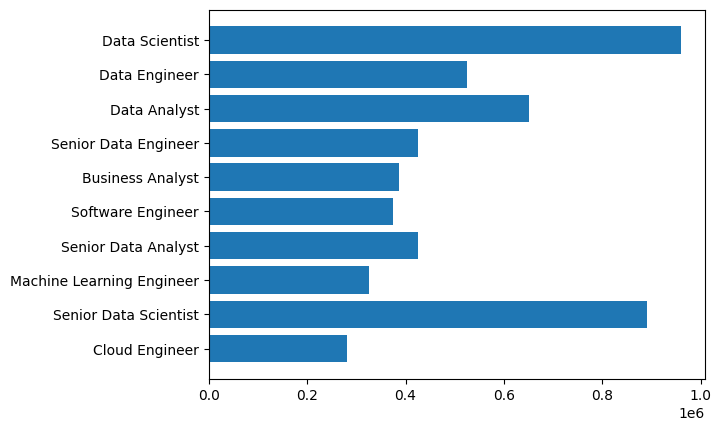

In [16]:
import matplotlib.pyplot as plt
plt.barh(y=df_clean['job_title_short'], width=df_clean['salary_year_avg'])
plt.gca().invert_yaxis()
plt.show()

### **3. Analisi vendite (dataset tips)**

Esegui un’**analisi esplorativa** focalizzata sulle **vendite giornaliere**.  
Analizza i seguenti aspetti per ogni giorno (`day`):

* Il **conto medio** (`total_bill`)
* Il **numero totale di osservazioni** (conteggio delle righe)
* Il **valore minimo e massimo** del conto (`total_bill` → `min` / `max`)

* Crea una nuova colonna `conto_per_persona` che sia:  
  `total_bill / size`

* Trova il giorno con il **conto medio più alto**

Rappresenta graficamente il **conto medio (`total_bill`) per giorno** usando un **grafico a barre**.  
Ordina i dati dal valore più alto al più basso.  
Aggiungi titolo ed etichette agli assi.

In [17]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [18]:
df.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='str')

In [19]:
df_groped = df.groupby(by="day")

In [20]:
df_groped['total_bill'].mean()

day
Fri     17.151579
Sat     20.441379
Sun     21.410000
Thur    17.682742
Name: total_bill, dtype: float64

In [21]:
size = df_groped['total_bill'].count()
size

day
Fri     19
Sat     87
Sun     76
Thur    62
Name: total_bill, dtype: int64

In [22]:
max_bill = df_groped['total_bill'].max()
min_bill = df_groped['total_bill'].min()
print(f"Max:\n{max_bill}\n\nMin:\n{min_bill}")

Max:
day
Fri     40.17
Sat     50.81
Sun     48.17
Thur    43.11
Name: total_bill, dtype: float64

Min:
day
Fri     5.75
Sat     3.07
Sun     7.25
Thur    7.51
Name: total_bill, dtype: float64


In [28]:
df['conto_per_persona'] = df['total_bill'] / df['size']
df['conto_per_persona']

0       8.495000
1       3.446667
2       7.003333
3      11.840000
4       6.147500
         ...    
239     9.676667
240    13.590000
241    11.335000
242     8.910000
243     9.390000
Name: conto_per_persona, Length: 244, dtype: float64

In [44]:
mean_by_day = df.groupby('day')['conto_per_persona'].mean().sort_values(ascending=False)
mean_by_day.idxmax(), mean_by_day.max()

('Sat', np.float64(8.187231800766284))

In [48]:
mean_bill_by_day = df.groupby('day')['total_bill'].mean().sort_values(ascending=False)
mean_bill_by_day

day
Sun     21.410000
Sat     20.441379
Thur    17.682742
Fri     17.151579
Name: total_bill, dtype: float64

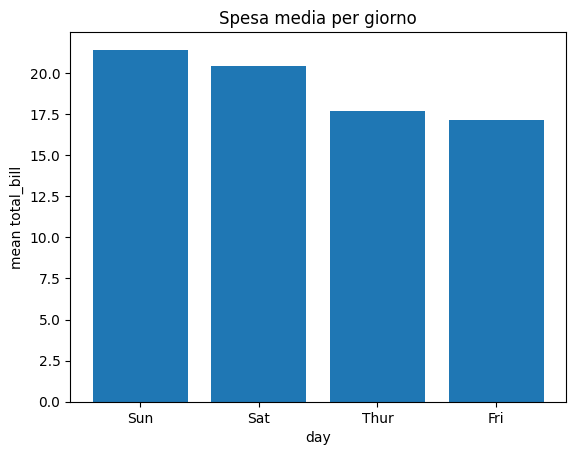

In [52]:
plt.bar(mean_bill_by_day.index, mean_bill_by_day.values)
plt.xlabel('day')
plt.ylabel('mean total_bill')
plt.title('Spesa media per giorno')
plt.show()